In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as sco 
import seaborn as sns

In [4]:
daily_returns = pd.read_csv(
    "data/processed/daily_returns.csv",
    index_col=0,
    parse_dates=True
)

adj_close = pd.read_csv(
    "data/processed/adj_close.csv",
    index_col=0,
    parse_dates=True
)

metrics_table = pd.read_csv(
    "data/processed/metrics_table.csv",
    index_col=0
)

daily_rfr = pd.read_csv(
    "data/processed/daily_risk_free_rate.csv",
    index_col = 0
)

In [5]:
from src.metrics import negative_sharpe

In [6]:
long_returns = daily_returns.reset_index().melt(id_vars = 'Date', value_vars = daily_returns.columns)
long_returns.columns = ['Date', 'Asset','Return']
long_returns['Date'] = pd.to_datetime(long_returns['Date'])
long_returns = long_returns.sort_values(['Asset','Date'])
daily_rfr.index = pd.to_datetime(daily_rfr.index)
long_returns = long_returns.merge(
    daily_rfr,
    left_on='Date',
    right_index= True,
    how = 'left'
)
long_returns['excess_return'] = long_returns['Return'] - long_returns['daily_rfr']

In [7]:
long_adj_close = adj_close.reset_index().melt(id_vars = 'Date', value_vars = adj_close.columns).set_index('Date')
long_adj_close.columns = ['Asset','Adj_close']
long_adj_close = long_adj_close.sort_values(['Asset','Date'])
long_adj_close['log_return'] = (
    long_adj_close.groupby('Asset')['Adj_close'].transform(
        lambda x: np.log(x).diff())
    )
long_adj_close = long_adj_close.dropna(subset = ['log_return'])
long_data = long_returns.merge(
    long_adj_close,
    on = ('Date', 'Asset'),
    how = 'inner'
)
long_data['Date'] = pd.to_datetime(long_data['Date'])

## Static Optimized Portfolio - Baseline

In [8]:
import importlib
import src.config as config

importlib.reload(config)

asset_class_caps = config.asset_class_caps
portfolio_groups = config.portfolio_groups
asset_bounds = config.asset_bounds

from src.optimization import build_constraints
tb_portfolio = long_data.copy()
port_start = tb_portfolio['Date'].iloc[0]
port_end = tb_portfolio['Date'].iloc[-1]

In [9]:
tickers = daily_returns.columns

constraints = build_constraints(
    tickers,
    config.portfolio_groups,
    config.asset_class_caps
)

bounds = tuple(asset_bounds for _ in range(len(tickers)))

## Random Weights ##

initial_weights = {
    "SPY": 0.10,
    "QQQ": 0.08,
    "IWM": 0.07,
    "EFA": 0.08,
    "EEM": 0.07,
    "AGG": 0.10,
    "TLT": 0.08,
    "LQD": 0.07,
    "GLD": 0.075,
    "VNQ": 0.075,
    "MTUM": 0.04,
    "VLUE": 0.04,
    "QUAL": 0.035,
    "USMV": 0.035
}

initial = pd.Series(initial_weights).reindex(daily_returns.columns).values

In [10]:
daily_returns_1 = daily_returns.reset_index()
daily_returns_start = daily_returns_1['Date'].iloc[0]
first_period = daily_returns_1[daily_returns_1['Date'].between(daily_returns_start, daily_returns_start.to_period('Y').end_time)]
first_period_mean_returns = first_period.drop(columns = 'Date').mean()


In [11]:
first_period_cov_matrix = first_period.drop(columns = ['Date']).cov()
first_period_rf_rate = daily_rfr.iloc[0: int(len(first_period['Date']))].mean()

In [12]:
first_period_optimization = sco.minimize(
    negative_sharpe,
    initial,
    args = (first_period_mean_returns, first_period_cov_matrix, first_period_rf_rate),
    method = 'SLSQP',
    bounds = bounds,
    constraints= constraints
)

initial_weights_ = first_period_optimization.x
first_period_weights = pd.Series(initial_weights_, index = daily_returns.columns)

In [13]:
long_data.head()

,Date,Asset,Return,daily_rfr,excess_return,Adj_close,log_return
0,2021-07-13,AGG,-0.002163,0.000002,-0.002165,98.387383,-0.002165
1,2021-07-14,AGG,0.003381,0.000002,0.003378,98.719986,0.003375
2,2021-07-15,AGG,0.002160,0.000002,0.002158,98.933228,0.002158
3,2021-07-16,AGG,-0.000862,0.000002,-0.000864,98.847931,-0.000863
4,2021-07-19,AGG,0.005263,0.000002,0.005261,99.368202,0.005250


In [14]:
## CREATING WEIGHTS ##
long_data['weights'] = long_data['Asset'].map(first_period_weights)

if np.isclose(first_period_weights.sum(), 1):
    print("Weights Equal 1")
else:
    print("Does Not Equal 1")


Weights Equal 1


In [15]:
## ESTABLISHING BASELINE PERFORMANCE FOR THE INITITAL PORTFOLIO ##

evaluation_data = long_data[~long_data['Date'].isin(first_period['Date'])]

evaluation_data['portfolio_return'] = evaluation_data['weights'] * evaluation_data['Return']

weighted_returns_df = pd.DataFrame(evaluation_data.groupby('Date')['portfolio_return'].sum()).reset_index()

weighted_returns_df['rolling_return'] = weighted_returns_df['portfolio_return'].rolling(21).mean()
weighted_returns_df['rolling_vol'] =  weighted_returns_df['portfolio_return'].rolling(21).std() * np.sqrt(252)

weighted_returns_df = weighted_returns_df.merge(
    daily_rfr,
    left_on='Date',
    right_index= True,
    how = 'left'
).rename(columns={'daily_rfr':'rf_rate'})

weighted_returns_df['portfolio_value'] = (
    1 + weighted_returns_df['portfolio_return']
).cumprod()
weighted_returns_df['running_peak'] = weighted_returns_df['portfolio_value'].cummax()
weighted_returns_df['drawdown'] = (
    weighted_returns_df['portfolio_value'] / weighted_returns_df['running_peak'] - 1
)


(-0.06, 0.06)

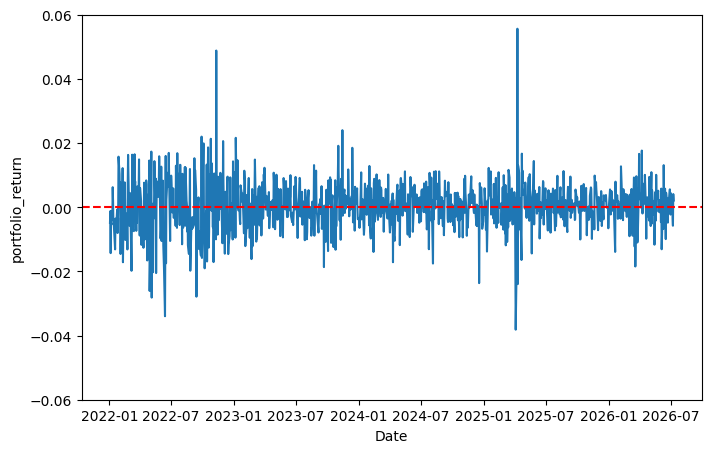

In [16]:
plt.figure(figsize= (8,5))
sns.lineplot(data = weighted_returns_df, x = 'Date', y = 'portfolio_return')
plt.axhline(y=weighted_returns_df['portfolio_return'].mean(), color='red', linestyle='--')
plt.ylim(-0.06, 0.06)

## Time-Based Rebalancing Strategy

In [17]:
## Function for evaluating by date ## 
## Period Weights to be an asset indexed series of predetermined weights ##
## df will be a time-series of portfolio return data ## 
def evaluate_period(start_date, end_date, period_weights, df):
    eval_data = df[df['Date'].between(start_date, end_date)].copy()

    eval_data['weights'] = eval_data['Asset'].map(period_weights)
    eval_data['weighted_returns'] = eval_data['weights'] * eval_data['Return']
    daily_rfr = pd.Series(eval_data.groupby('Date')['daily_rfr'].mean()).values

    daily_portfolio = (
        eval_data
        .groupby('Date', as_index=False)['weighted_returns']
        .sum()
        .rename(columns={'weighted_returns': 'portfolio_return'})
    )
    daily_portfolio['rf_rate'] = daily_rfr
    daily_portfolio['portfolio_value'] = (
    1 + daily_portfolio['portfolio_return']
    ).cumprod()

    daily_portfolio['running_peak'] = daily_portfolio['portfolio_value'].cummax()

    daily_portfolio['drawdown'] = (
        daily_portfolio['portfolio_value'] / daily_portfolio['running_peak'] - 1
    )

    summary = {
        'start_date': start_date,
        'end_date': end_date,
        'period_return': daily_portfolio['portfolio_value'].iloc[-1] - 1,
        'volatility': daily_portfolio['portfolio_return'].std() * np.sqrt(252),
        'max_drawdown': daily_portfolio['drawdown'].min(),
        'avg_daily_return': daily_portfolio['portfolio_return'].mean()
    }

    asset_growth = (
        eval_data
        .sort_values(['Asset', 'Date'])
        .groupby('Asset')['Return']
        .apply(lambda x: (1 + x).prod())
    )

    end_values = period_weights * asset_growth
    end_weights = end_values / end_values.sum()

    return daily_portfolio, summary, end_weights


In [18]:
def optimizer(df, start_date, end_date):

    opt_df = df[df['Date'].between(start_date, end_date)].copy()

    rf = opt_df['daily_rfr'].mean()

    returns = (
        opt_df.pivot(index = 'Date', columns = 'Asset', values = 'Return')
        )
    returns_mean = returns.mean()
    returns_cov = returns.cov()
    
    optimized = sco.minimize(
    negative_sharpe,
    initial, 
    args = (returns_mean, returns_cov, rf),
    method = "SLSQP",
    bounds = bounds,
    constraints = constraints
    )
    
    return pd.Series(optimized.x, index=returns.columns)

In [19]:
def build_evaluation_schedule(df, date_col='Date', freq='Q', lookback_obs=252, min_obs=63):
    dates = (
        pd.to_datetime(df[date_col])
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    port_start = dates.iloc[0]
    port_end = dates.iloc[-1]

    if freq == 'Q':
        hold_starts = pd.date_range(
            port_start.to_period('Q').start_time,
            port_end,
            freq='QS'
        )
        offset = pd.offsets.QuarterEnd(0)

    elif freq == 'Y':
        hold_starts = pd.date_range(
            port_start.to_period('Y').start_time,
            port_end,
            freq='YS'
        )
        offset = pd.offsets.YearEnd(0)

    rows = []

    for hold_start in hold_starts:
        hold_end = min(hold_start + offset, port_end)

        available_est_dates = dates[dates < hold_start]

        if len(available_est_dates) < min_obs:
            continue

        est_dates = available_est_dates.tail(lookback_obs)

        rows.append({
            'est_start': est_dates.iloc[0],
            'est_end': est_dates.iloc[-1],
            'hold_start': hold_start,
            'hold_end': hold_end,
            'est_obs': len(est_dates)
        })

    return pd.DataFrame(rows)

In [20]:
evaluation_schedule_quarterly = build_evaluation_schedule(
    tb_portfolio,
    date_col='Date',
    freq= 'Q',
    lookback_obs=252,
    min_obs=63
)

In [21]:
evaluation_schedule_annual = build_evaluation_schedule(
    tb_portfolio,
    date_col='Date',
    freq = 'Y',
    lookback_obs=252,
)

In [22]:
## Annual Evaluation ##

def run_rebalance_backtest(df, schedule, initial_daily=None, initial_summary=None):
    eval_list = []
    daily_list = []
    weights_list = []

    rebalance_counter = pd.DataFrame(columns= ['Date','Rebalanced'])

    if initial_summary is not None:
        eval_list.append(initial_summary)

    if initial_daily is not None:
        daily_list.append(initial_daily)

    for _, period in schedule.iterrows():

        weights = optimizer(
            df = df,
            start_date = period['est_start'],
            end_date = period['est_end']
        )

        weights_dict = weights.to_dict()

        daily, summary, ending_weights = evaluate_period(
        start_date = period['hold_start'],
        end_date = period['hold_end'],
        period_weights=weights,
        df = df
        )

        weights_list.append({
            "Date": daily["Date"].min(),
            "weight_type": "starting",
            **weights_dict
        })

        rebalance_date = daily["Date"].min()
        rebalance_counter.loc[len(rebalance_counter)] = [rebalance_date, 1]

        summary['est_start'] = period['est_start']
        summary['est_end'] = period['est_end']
        summary['hold_start'] = period['hold_start']
        summary['hold_end'] = period['hold_end']
        summary['est_obs'] = period['est_obs']

        eval_list.append(summary)
        daily_list.append(daily)


        weights_list.append({
            "Date": daily["Date"].max(),
            "weight_type": "ending",
            **ending_weights.to_dict()
        })

    daily_portfolio_df = (
        pd.concat(daily_list)
        .sort_values('Date')
        .reset_index(drop=True)
    )

    daily_portfolio_df['portfolio_value'] = (
        1 + daily_portfolio_df['portfolio_return']
    ).cumprod()

    daily_portfolio_df = daily_portfolio_df.merge(
        rebalance_counter,
        on = 'Date',
        how = 'left'
    ).fillna(0)



    return pd.DataFrame(eval_list), daily_portfolio_df, pd.DataFrame(weights_list)


eval_df_annually, daily_df_annually, annual_weights_frame = run_rebalance_backtest(
    df=tb_portfolio,
    schedule=evaluation_schedule_annual,
    initial_daily=None,
    initial_summary=None
)


(-0.06, 0.06)

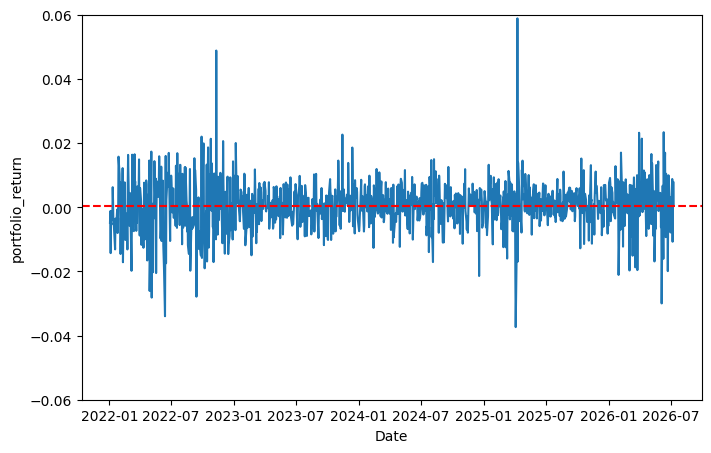

In [23]:
plt.figure(figsize= (8,5))
sns.lineplot(data = daily_df_annually, x = 'Date', y = 'portfolio_return')
plt.axhline(y=daily_df_annually['portfolio_return'].mean(), color='red', linestyle='--')
plt.ylim(-0.06, 0.06)

In [24]:
quarterly_eval_df, daily_df_quarterly, quarterly_weights_frame = run_rebalance_backtest(
    df = tb_portfolio, 
    schedule = evaluation_schedule_quarterly, 
    initial_daily = None,
    initial_summary= None)

(-0.06, 0.06)

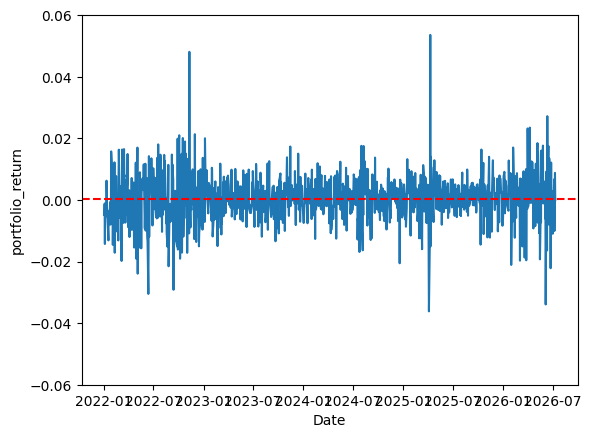

In [25]:
sns.lineplot(data = daily_df_quarterly, x = 'Date', y = 'portfolio_return')
plt.axhline(y=daily_df_quarterly['portfolio_return'].mean(), color='red', linestyle='--')
plt.ylim(-0.06, 0.06)

## Band-Based Rebalancing Strategy

In [51]:
current_weights = first_period_weights.copy()

def run_band_backtest(df, schedule, band, starting_weights, initial_daily=None, initial_summary=None):
    
    eval_list = []
    daily_list = []
    weights_list = []

    rebalance_counter = pd.DataFrame(columns= ['Date','Rebalanced'])

    if initial_summary is not None:
        eval_list.append(initial_summary)

    if initial_daily is not None:
        daily_list.append(initial_daily)

    for _, period in schedule.iterrows():

        daily, summary, ending_weights = evaluate_period(
            start_date=period['hold_start'],
            end_date=period['hold_end'],
            period_weights=starting_weights,
            df=df
        )

        rebalance_needed = (ending_weights > band).any()

        summary['est_start'] = period['est_start']
        summary['est_end'] = period['est_end']
        summary['hold_start'] = period['hold_start']
        summary['hold_end'] = period['hold_end']
        summary['est_obs'] = period['est_obs']
        summary['rebalanced'] = rebalance_needed

        eval_list.append(summary)
        daily_list.append(daily)
        weights_list.append({
            "Date": daily["Date"].min(),
            "weight_type": "starting",
            **starting_weights.to_dict()
        })
        weights_list.append({
            "Date": daily["Date"].max(),
            "weight_type": "ending",
            **ending_weights.to_dict()
        })


        if rebalance_needed:
            print(f"Rebalance at: {daily["Date"].min()}")
            
            starting_weights = optimizer(
            df=df,
            start_date=period['est_start'],
            end_date=period['est_end']
            )
            rebalance_counter.loc[len(rebalance_counter)] = [daily["Date"].min(), 1]

        else:
            starting_weights = ending_weights.copy() 


    daily_portfolio_df = (
        pd.concat(daily_list)
        .sort_values('Date')
        .reset_index(drop=True)
    )

    daily_portfolio_df['portfolio_value'] = (
        1 + daily_portfolio_df['portfolio_return']
    ).cumprod()

    daily_portfolio_df = daily_portfolio_df.merge(
        rebalance_counter,
        on = 'Date',
        how = 'left'
        ).fillna(0)

    return pd.DataFrame(eval_list), daily_portfolio_df, pd.DataFrame(weights_list)


eval_df_quarterly_band, daily_df_quarterly_band, band_weights_frame = run_band_backtest(
    df=tb_portfolio,
    schedule=evaluation_schedule_quarterly,
    band = 0.155,
    starting_weights= current_weights,
    initial_daily=None,
    initial_summary=None
)

Rebalance at: 2022-04-01 00:00:00
Rebalance at: 2022-10-03 00:00:00
Rebalance at: 2023-04-03 00:00:00
Rebalance at: 2023-10-02 00:00:00
Rebalance at: 2024-01-02 00:00:00
Rebalance at: 2024-04-01 00:00:00
Rebalance at: 2024-07-01 00:00:00
Rebalance at: 2024-10-01 00:00:00
Rebalance at: 2025-01-02 00:00:00
Rebalance at: 2025-04-01 00:00:00
Rebalance at: 2025-07-01 00:00:00
Rebalance at: 2025-10-01 00:00:00
Rebalance at: 2026-01-02 00:00:00
Rebalance at: 2026-04-01 00:00:00
Rebalance at: 2026-07-01 00:00:00


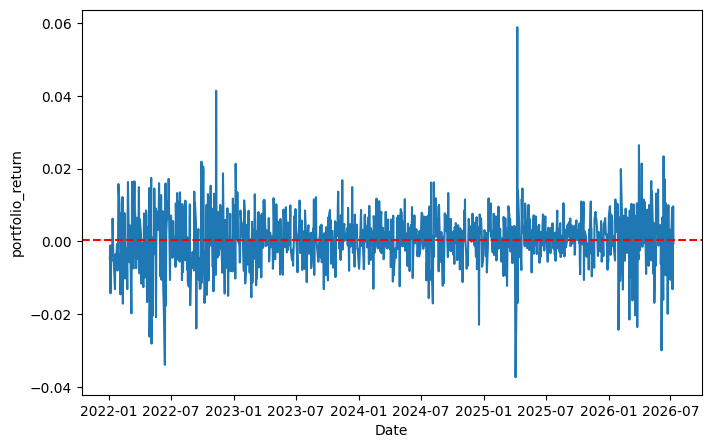

In [52]:
plt.figure(figsize= (8,5))
sns.lineplot(data = daily_df_quarterly_band, x = 'Date', y = 'portfolio_return')
plt.axhline(y=daily_df_quarterly_band['portfolio_return'].mean(), color='red', linestyle='--')


In [53]:
def compare_strategy(name, daily_returns, eval_df=None):

    daily_returns = daily_returns.copy()

    total_return = daily_returns['portfolio_value'].iloc[-1] - 1
    
    volatility = daily_returns['portfolio_return'].std() * np.sqrt(252)

    annual_return = daily_returns['portfolio_return'].mean() * 252
    annual_rf = daily_returns['rf_rate'].mean() * 252

    sharpe = (annual_return-annual_rf) / volatility

    max_drawdown = (
        daily_returns['portfolio_value'] /
        daily_returns['portfolio_value'].cummax() - 1
    ).min()


    if 'Rebalanced' in daily_returns.columns:
        rebalances = daily_returns['Rebalanced'].sum()
    else: 
        rebalances = 0
        
    summary_dict = {'strategy': name,
                    'eval_start': daily_returns['Date'].iloc[0],
                    'eval_end' : daily_returns['Date'].iloc[-1],
                    'total_return' : total_return,
                    'annual_return': annual_return,
                    'volatility' : volatility,
                    'sharpe' : sharpe,
                    'max_dd' : max_drawdown,
                    'rebalances' : rebalances
                    }
    return pd.Series(summary_dict)

In [54]:
baseline_summary = compare_strategy(
    name = 'No_Rebalancing',
    daily_returns= weighted_returns_df
)

annual_summary = compare_strategy(
    name = 'Annual_Reblancing',
    daily_returns= daily_df_annually,
)

quarterly_summary = compare_strategy(
    name = 'Quarterly_Reblancing',
    daily_returns= daily_df_quarterly
)

quarterly_band_summary = compare_strategy(
    name = 'Quarterly_Band_Reblancing',
    daily_returns= daily_df_quarterly_band
)

Summary = pd.DataFrame([baseline_summary, annual_summary, quarterly_summary, quarterly_band_summary])
Summary

,strategy,eval_start,eval_end,total_return,annual_return,volatility,sharpe,max_dd,rebalances
0,No_Rebalancing,2022-01-03,2026-07-10,0.223792,0.052020,0.119255,0.089342,-0.249180,0.0
1,Annual_Reblancing,2022-01-03,2026-07-10,0.450659,0.090209,0.122206,0.399683,-0.249180,5.0
2,Quarterly_Reblancing,2022-01-03,2026-07-10,0.517620,0.100093,0.120918,0.485684,-0.230324,19.0
3,Quarterly_Band_Reblancing,2022-01-03,2026-07-10,0.505097,0.098198,0.120463,0.471787,-0.240694,15.0


In [55]:
tb_portfolio.to_csv("data/processed/tb_portfolio")
weighted_returns_df.to_csv("data/outputs/baseline_portfolio")
daily_df_annually.to_csv("data/outputs/annually_reblanced_portfolio")
daily_df_quarterly.to_csv("data/outputs/quarterly_reblanced_portfolio")
daily_df_quarterly_band.to_csv("data/outputs/quarterly_reblanced_byband_portfolio")

annual_weights_frame.to_csv("data/outputs/annually_rebalanced_weights")
quarterly_weights_frame.to_csv("data/outputs/quarterly_rebalanced_weights")
band_weights_frame.to_csv("data/outputs/quarterly_rebalanced_byband_weights")